# Random Forest Human Movement Prediction: Model Evaluation Notebook

This notebook evaluates the **human movement prediction model** used by the maze escape game.  
The model predicts the player's next direction (`up`, `down`, `left`, `right`) from the current game state.

本 notebook 完成三个实验：

1. **Prediction accuracy analysis**：评估下一步方向预测的准确率，并检查当前数据是否支持 rolling prediction。  
2. **Feature importance / SHAP analysis**：分析哪些特征对 Random Forest 的预测贡献最大。  
3. **Ablation study**：删除不同类别的特征，观察模型性能下降，从而验证特征是否有效。

> Important: the current `replay_log.jsonl` only contains `features` and one-step `label`. Therefore, it can rigorously support **one-step direction prediction**, feature importance, and ablation study. A strict 3-step rolling position error needs trajectory fields such as `game_id`, `turn`, `human_pos`, and `future_pos_3`.

## 0. Environment and file settings

Put this notebook in the project root folder, the same level as `replay_log.jsonl`.

Expected structure:

```text
maze-escape-ai/
├── replay_log.jsonl
├── rf_prediction_evaluation.ipynb
├── models/
└── results/
```

In [17]:
from __future__ import annotations

import json
import os
import pickle
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

RATATE = 42
REPLAY_LOG = Path("replay_log.jsonl")
MODEL_DIR = Path("models")
RESULT_DIR = Path("results")
FIGURE_DIR = RESULT_DIR / "figures"

MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

MODEL_PATH = MODEL_DIR / "direction_model_rf_16_features.pkl"
FEATURE_IMPORTANCE_CSV = RESULT_DIR / "feature_importance.csv"
ABLATION_CSV = RESULT_DIR / "ablation_results.csv"

# ==========================================================
# MCM-style academic visualization theme
# ==========================================================
# Design target: clean white background, muted but legible colors,
# high-DPI export, consistent typography, and minimal chart clutter.
MCM_COLORS = {
    "navy": "#1F3A5F",
    "blue": "#3A78B7",
    "teal": "#2A9D8F",
    "mint": "#8FC6B3",
    "gold": "#E9C46A",
    "coral": "#E76F51",
    "purple": "#6D5A8D",
    "ink": "#1F2937",
    "gray": "#6B7280",
    "light_gray": "#E5E7EB",
    "panel": "#F8FAFC",
}

DIRECTION_COLORS = {
    "down": MCM_COLORS["blue"],
    "left": MCM_COLORS["teal"],
    "right": MCM_COLORS["gold"],
    "up": MCM_COLORS["coral"],
}

CONFUSION_CMAP = LinearSegmentedColormap.from_list(
    "mcm_confusion",
    ["#F8FAFC", "#DDEFE8", "#8FC6B3", "#2A9D8F", "#1F3A5F"],
)

# Blue-low / pink-high SHAP palette, matching the common beeswarm convention.
SHAP_CMAP = LinearSegmentedColormap.from_list(
    "mcm_shap_blue_pink",
    ["#2B6CB0", "#F7F7F7", "#D81B60"],
)

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial", "DejaVu Sans", "Microsoft YaHei", "SimHei",
        "Noto Sans CJK SC", "Arial Unicode MS"
    ],
    "axes.edgecolor": "#334155",
    "axes.linewidth": 0.9,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
    "grid.color": "#CBD5E1",
    "grid.linewidth": 0.6,
    "grid.alpha": 0.55,
    "axes.unicode_minus": False,
})


def save_figure(path: Path):
    """Save a figure with report-ready resolution and tight margins."""
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")


def polish_axes(ax, grid_axis="y"):
    """Apply consistent academic chart styling."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#334155")
    ax.spines["bottom"].set_color("#334155")
    if grid_axis:
        ax.grid(True, axis=grid_axis)
        ax.set_axisbelow(True)
    return ax


## 1. Load and inspect the replay log

Each record in `replay_log.jsonl` should contain:

```json
{
  "features": {...},
  "label": "up/down/left/right"
}
```

The current dataset records the state before a player movement and uses the actual movement direction as the label.

In [18]:
def load_jsonl(path: Path) -> List[dict]:
    records = []
    if not path.exists():
        raise FileNotFoundError(f"Cannot find {path.resolve()}")

    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                print(f"Skip invalid JSON at line {line_no}")
                continue
            if "features" in record and "label" in record:
                records.append(record)
    return records

records = load_jsonl(REPLAY_LOG)
print(f"Loaded records: {len(records)}")
records[0]

Loaded records: 2073


{'features': {'human_row': 0.5666666666666667,
  'human_col': 0.6,
  'monster_row': 0.0,
  'monster_col': 0.8666666666666667,
  'wall_up': 1,
  'wall_down': 1,
  'wall_left': 0,
  'wall_right': 0,
  'prev_up_1': 0,
  'prev_down_1': 0,
  'prev_left_1': 0,
  'prev_right_1': 0,
  'prev_up_2': 0,
  'prev_down_2': 0,
  'prev_left_2': 0,
  'prev_right_2': 0},
 'label': 'left'}

In [19]:
def records_to_dataframe(records: List[dict]) -> pd.DataFrame:
    rows = []
    for record in records:
        row = dict(record["features"])
        row["label"] = record["label"]
        rows.append(row)
    return pd.DataFrame(rows)

df = records_to_dataframe(records)
print("Data shape:", df.shape)
display(df.head())
print("\nColumns:")
print(list(df.columns))

Data shape: (2073, 17)


,human_row,human_col,monster_row,monster_col,wall_up,wall_down,wall_left,wall_right,prev_up_1,prev_down_1,prev_left_1,prev_right_1,prev_up_2,prev_down_2,prev_left_2,prev_right_2,label
0,0.566667,0.600000,0.000000,0.866667,1,1,0,0,0,0,0,0,0,0,0,0,left
1,0.566667,0.566667,0.966667,0.833333,0,1,0,0,0,0,1,0,0,0,0,0,left
2,0.566667,0.533333,0.933333,0.800000,0,1,0,0,0,0,1,0,0,0,1,0,left
3,0.566667,0.500000,0.900000,0.766667,0,1,1,0,0,0,1,0,0,0,1,0,up
4,0.533333,0.500000,0.933333,0.733333,1,0,0,0,1,0,0,0,0,0,1,0,left



Columns:
['human_row', 'human_col', 'monster_row', 'monster_col', 'wall_up', 'wall_down', 'wall_left', 'wall_right', 'prev_up_1', 'prev_down_1', 'prev_left_1', 'prev_right_1', 'prev_up_2', 'prev_down_2', 'prev_left_2', 'prev_right_2', 'label']


### Feature format used in this notebook

This notebook uses the 16-feature format currently found in the provided replay log:

- Player and monster position: `human_row`, `human_col`, `monster_row`, `monster_col`
- Surrounding wall information: `wall_up`, `wall_down`, `wall_left`, `wall_right`
- Previous direction one-hot features: `prev_*_1`, `prev_*_2`

This feature set is richer than the 8-feature version (`rel_row`, `rel_col`, `prev1`, `prev2`) and directly matches the uploaded experimental data.

In [20]:
POSITION_FEATURES = [
    "human_row", "human_col",
    "monster_row", "monster_col",
]

WALL_FEATURES = [
    "wall_up", "wall_down", "wall_left", "wall_right",
]

HISTORY_FEATURES = [
    "prev_up_1", "prev_down_1", "prev_left_1", "prev_right_1",
    "prev_up_2", "prev_down_2", "prev_left_2", "prev_right_2",
]

FULL_FEATURES = POSITION_FEATURES + WALL_FEATURES + HISTORY_FEATURES
LABEL_COL = "label"

missing = [col for col in FULL_FEATURES + [LABEL_COL] if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.dropna(subset=FULL_FEATURES + [LABEL_COL]).copy()

for col in FULL_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=FULL_FEATURES + [LABEL_COL]).copy()

print("Cleaned data shape:", df.shape)
print("Label distribution:")
display(df[LABEL_COL].value_counts().rename("count").to_frame())

Cleaned data shape: (2073, 17)
Label distribution:


,count
label,
left,911
down,580
up,363
right,219


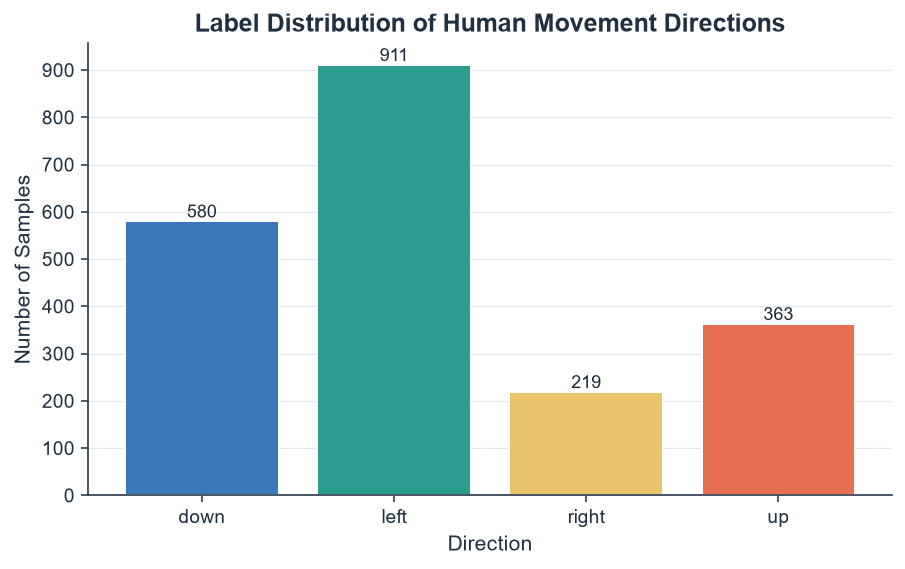

In [21]:
# Label distribution plot: MCM-style muted palette
label_counts = df[LABEL_COL].value_counts().sort_index()
bar_colors = [DIRECTION_COLORS.get(label, MCM_COLORS["blue"]) for label in label_counts.index]

fig, ax = plt.subplots(figsize=(6.6, 4.2))
bars = ax.bar(
    label_counts.index,
    label_counts.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=1.0,
)

ax.set_title("Label Distribution of Human Movement Directions")
ax.set_xlabel("Direction")
ax.set_ylabel("Number of Samples")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
polish_axes(ax, grid_axis="y")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=9,
        color=MCM_COLORS["ink"],
    )

save_figure(FIGURE_DIR / "label_distribution.png")
plt.show()


## 2. Experiment 1: Prediction accuracy analysis

This experiment trains a Random Forest classifier and evaluates one-step direction prediction.

Metrics:

- **Accuracy**: overall proportion of correct predictions.
- **Balanced accuracy**: average recall over all classes; useful when class distribution is imbalanced.
- **Confusion matrix**: shows which directions are frequently confused.

### About rolling prediction

A strict multi-step rolling prediction evaluation requires true future positions or trajectory IDs.  
The current data only contains `features + one-step label`, so this notebook provides a one-step prediction evaluation and a feasibility check for rolling analysis.

In [22]:
def make_split(df: pd.DataFrame, features: List[str]):
    X = df[features]
    y = df[LABEL_COL]
    return train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y,
    )


def train_rf_classifier(
    X_train: pd.DataFrame,
    y_train: pd.Series,
) -> RandomForestClassifier:
    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    return model


def evaluate_model(model, X_test, y_test, title="Model") -> dict:
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    bal_acc = balanced_accuracy_score(y_test, pred)
    report = classification_report(y_test, pred, digits=4)
    matrix = confusion_matrix(y_test, pred, labels=model.classes_)

    print(f"{title}")
    print(f"Accuracy          = {acc:.4f}")
    print(f"Balanced accuracy = {bal_acc:.4f}")
    print("\nClassification report:")
    print(report)
    print("Confusion matrix:")
    print(matrix)

    return {
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "classification_report": report,
        "confusion_matrix": matrix,
        "pred": pred,
    }

X_train, X_test, y_train, y_test = make_split(df, FULL_FEATURES)
rf_model = train_rf_classifier(X_train, y_train)
full_metrics = evaluate_model(rf_model, X_test, y_test, title="Full Random Forest Model")

with MODEL_PATH.open("wb") as f:
    pickle.dump(rf_model, f)
print(f"\nSaved model to: {MODEL_PATH}")

Full Random Forest Model
Accuracy          = 0.7277
Balanced accuracy = 0.7213

Classification report:
              precision    recall  f1-score   support

        down     0.7391    0.7328    0.7359       116
        left     0.8365    0.7308    0.7801       182
       right     0.6122    0.6818    0.6452        44
          up     0.5870    0.7397    0.6545        73

    accuracy                         0.7277       415
   macro avg     0.6937    0.7213    0.7039       415
weighted avg     0.7416    0.7277    0.7313       415

Confusion matrix:
[[ 85  13   4  14]
 [ 22 133   6  21]
 [  5   6  30   3]
 [  3   7   9  54]]

Saved model to: models\direction_model_rf_16_features.pkl


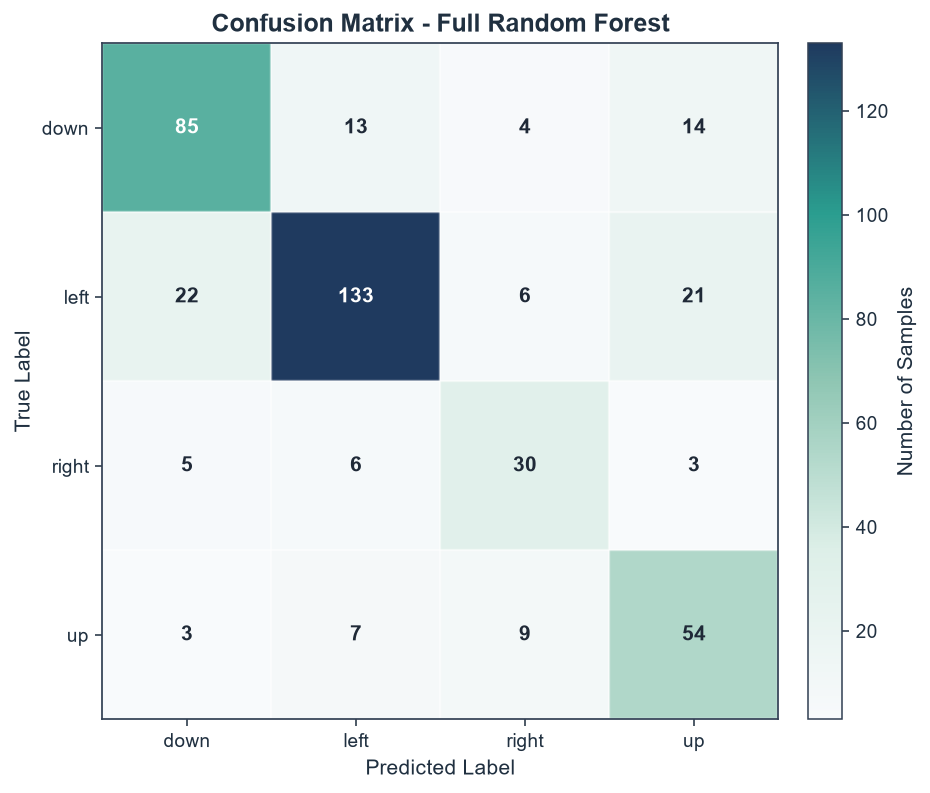

In [23]:
# Confusion matrix visualization: unified MCM color theme
cm = full_metrics["confusion_matrix"]
labels = list(rf_model.classes_)

fig, ax = plt.subplots(figsize=(6.6, 5.8))
im = ax.imshow(cm, interpolation="nearest", cmap=CONFUSION_CMAP)

ax.set_title("Confusion Matrix - Full Random Forest")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

threshold = cm.max() * 0.55 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        value = cm[i, j]
        text_color = "white" if value > threshold else MCM_COLORS["ink"]
        ax.text(
            j,
            i,
            f"{value:d}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=11,
            fontweight="bold",
        )

# Thin white cell borders for better report readability.
ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Number of Samples")
cbar.outline.set_linewidth(0.8)

save_figure(FIGURE_DIR / "confusion_matrix_full_model.png")
plt.show()


In [24]:
# Rolling prediction feasibility check
required_for_true_rolling = {
    "game_id", "turn", "human_pos", "next_human_pos", "future_pos_3"
}
current_columns = set(df.columns)
missing_for_rolling = required_for_true_rolling - current_columns

if missing_for_rolling:
    print("True 3-step rolling position-error evaluation is NOT supported by the current replay_log.jsonl.")
    print("Missing trajectory fields:", sorted(missing_for_rolling))
    print("\nCurrent data can support one-step direction prediction only.")
    print("To evaluate rolling prediction rigorously, future logs should include game_id, turn, human_pos, and future_pos_3.")
else:
    print("The dataset contains trajectory fields. You can extend this notebook to calculate 3-step grid-distance error.")

True 3-step rolling position-error evaluation is NOT supported by the current replay_log.jsonl.
Missing trajectory fields: ['future_pos_3', 'game_id', 'human_pos', 'next_human_pos', 'turn']

Current data can support one-step direction prediction only.
To evaluate rolling prediction rigorously, future logs should include game_id, turn, human_pos, and future_pos_3.


## 3. Experiment 2: Feature importance and SHAP analysis

This experiment explains which features are most important for the Random Forest model.

Two levels are included:

1. **Random Forest built-in feature importance**: simple and stable.
2. **Optional SHAP analysis**: more detailed model explanation if the `shap` package is installed.

For the report, Random Forest feature importance is usually enough. SHAP can be presented as an advanced interpretability analysis if the package runs correctly.

In [25]:
importance_df = pd.DataFrame({
    "feature": FULL_FEATURES,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)

importance_df.to_csv(FEATURE_IMPORTANCE_CSV, index=False)
print(f"Saved feature importance to: {FEATURE_IMPORTANCE_CSV}")
display(importance_df)

Saved feature importance to: results\feature_importance.csv


,feature,importance
1,human_col,0.104878
9,prev_down_1,0.100841
0,human_row,0.093152
3,monster_col,0.081439
4,wall_up,0.080707
2,monster_row,0.079877
11,prev_right_1,0.071377
5,wall_down,0.070070
6,wall_left,0.062325
10,prev_left_1,0.062050


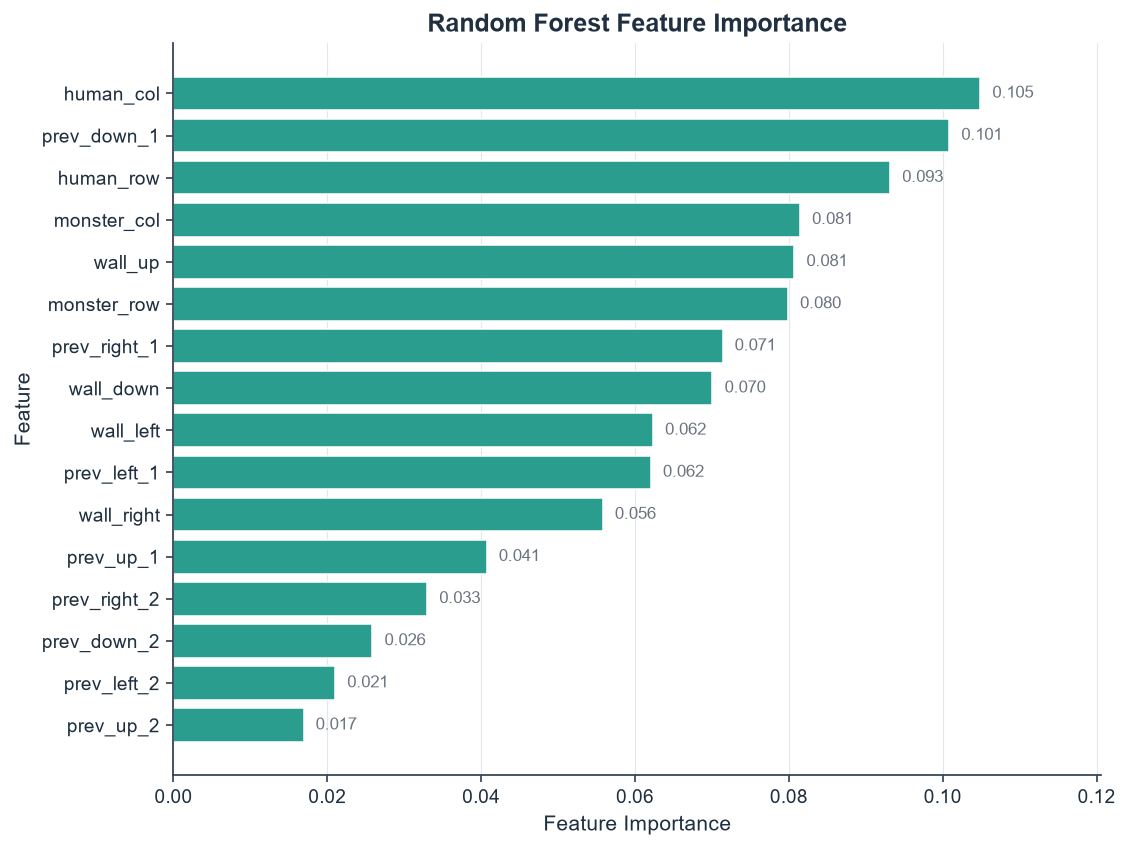

In [26]:
# Random Forest feature importance: MCM-style horizontal bar chart
plot_df = importance_df.sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8.2, 6.2))
bars = ax.barh(
    plot_df["feature"],
    plot_df["importance"],
    color=MCM_COLORS["teal"],
    edgecolor="white",
    linewidth=0.8,
)

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")
polish_axes(ax, grid_axis="x")

xmax = max(plot_df["importance"].max(), 1e-9)
ax.set_xlim(0, xmax * 1.15)
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + xmax * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=8.5,
        color=MCM_COLORS["gray"],
    )

save_figure(FIGURE_DIR / "feature_importance_rf.png")
plt.show()


SHAP is available. SHAP values computed on sample size: 300
Model classes: ['down', 'left', 'right', 'up']
Saved SHAP importance to: results\shap_feature_importance.csv


,feature,mean_abs_shap
9,prev_down_1,0.061398
4,wall_up,0.048413
10,prev_left_1,0.045563
5,wall_down,0.035097
6,wall_left,0.033917
11,prev_right_1,0.030685
1,human_col,0.028440
7,wall_right,0.024620
0,human_row,0.021891
8,prev_up_1,0.020659


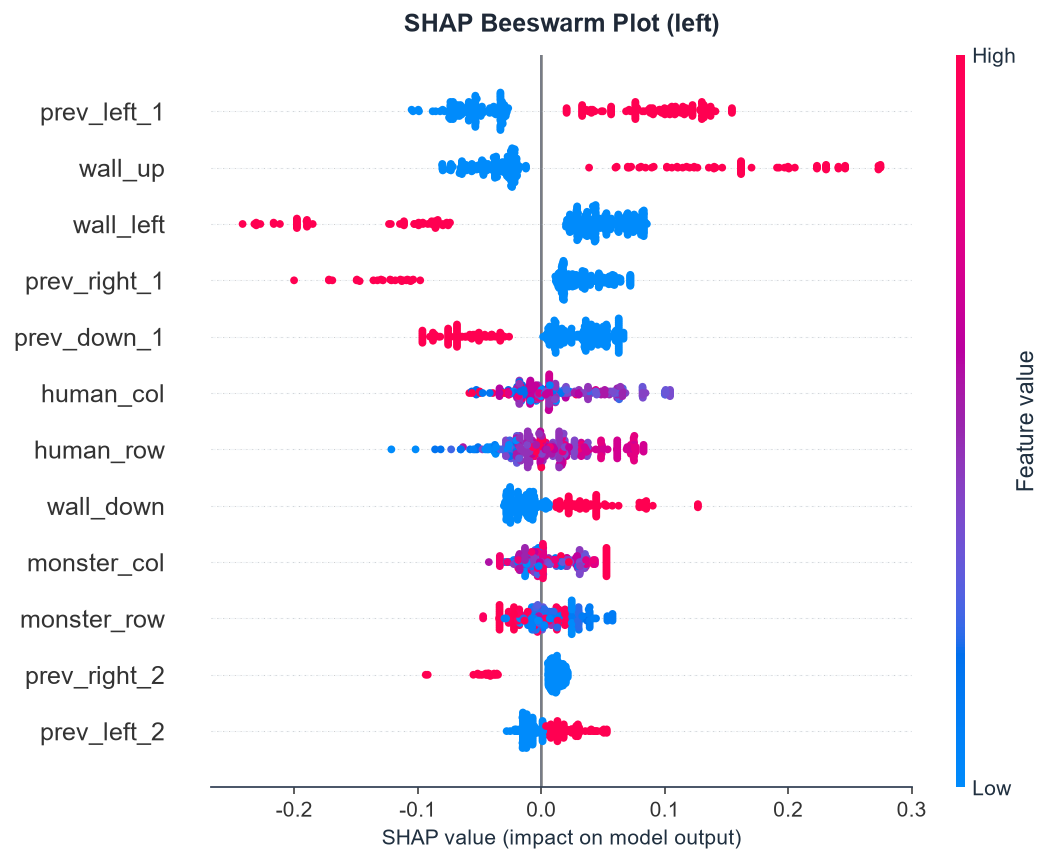

In [27]:
# Optional SHAP analysis: classic beeswarm plot + MCM-style charts elsewhere
try:
    import shap

    # Use a moderate sample size so the beeswarm remains readable and the notebook runs fast.
    shap_sample = X_test.sample(
        n=min(300, len(X_test)),
        random_state=RANDOM_STATE,
    )

    explainer = shap.TreeExplainer(rf_model)
    shap_values_raw = explainer.shap_values(shap_sample)

    print("SHAP is available. SHAP values computed on sample size:", len(shap_sample))
    print("Model classes:", list(rf_model.classes_))

    def get_class_shap_values(shap_values, class_index: int):
        """Return a 2D SHAP matrix with shape (n_samples, n_features)."""
        if isinstance(shap_values, list):
            return np.asarray(shap_values[class_index])

        arr = np.asarray(shap_values)
        if arr.ndim == 2:
            return arr
        if arr.ndim == 3:
            # Common SHAP formats:
            # 1) (n_samples, n_features, n_classes)
            # 2) (n_classes, n_samples, n_features)
            if arr.shape[2] == len(rf_model.classes_):
                return arr[:, :, class_index]
            if arr.shape[0] == len(rf_model.classes_):
                return arr[class_index, :, :]
        raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

    def mean_abs_multiclass_shap(shap_values):
        """Compute global mean absolute SHAP importance across classes."""
        if isinstance(shap_values, list):
            return np.mean([np.abs(np.asarray(v)).mean(axis=0) for v in shap_values], axis=0)
        arr = np.asarray(shap_values)
        if arr.ndim == 2:
            return np.abs(arr).mean(axis=0)
        if arr.ndim == 3:
            if arr.shape[2] == len(rf_model.classes_):
                return np.abs(arr).mean(axis=(0, 2))
            if arr.shape[0] == len(rf_model.classes_):
                return np.abs(arr).mean(axis=(0, 1))
        raise ValueError(f"Unexpected SHAP shape: {arr.shape}")

    mean_abs = mean_abs_multiclass_shap(shap_values_raw)
    shap_importance_df = pd.DataFrame({
        "feature": FULL_FEATURES,
        "mean_abs_shap": mean_abs,
    }).sort_values("mean_abs_shap", ascending=False)

    shap_importance_path = RESULT_DIR / "shap_feature_importance.csv"
    shap_importance_df.to_csv(shap_importance_path, index=False)
    print(f"Saved SHAP importance to: {shap_importance_path}")
    display(shap_importance_df)

    # ------------------------------------------------------------------
    # Classic SHAP beeswarm plot
    # ------------------------------------------------------------------
    # For a multiclass Random Forest, SHAP returns one explanation matrix per class.
    # The main report figure uses the most frequent true class in the test sample,
    # and additional class-specific beeswarm figures are saved below.
    sample_y = y_test.loc[shap_sample.index]
    main_class = sample_y.value_counts().idxmax()
    main_class_index = list(rf_model.classes_).index(main_class)
    shap_values_main = get_class_shap_values(shap_values_raw, main_class_index)

    # Do not use a custom MCM colormap here. The classic SHAP beeswarm convention
    # uses blue for low feature values and red/pink for high feature values.
    plt.figure(figsize=(8.0, 5.2))
    shap.summary_plot(
        shap_values_main,
        shap_sample,
        feature_names=FULL_FEATURES,
        plot_type="dot",
        max_display=min(12, len(FULL_FEATURES)),
        color_bar=True,
        show=False,
    )

    fig = plt.gcf()
    ax = plt.gca()
    ax.set_title(
        f"SHAP Beeswarm Plot ({main_class})",
        fontsize=13,
        fontweight="bold",
        pad=12,
        color=MCM_COLORS["ink"],
    )
    ax.set_xlabel("SHAP value (impact on model output)", fontsize=11)
    ax.axvline(0, color="#6B7280", linewidth=1.0, alpha=0.75)
    ax.grid(True, axis="y", linestyle="--", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    fig.tight_layout()
    fig.savefig(
        FIGURE_DIR / "shap_beeswarm_main.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )
    plt.show()

    # Save one classic beeswarm plot for each direction class.
    for class_index, class_name in enumerate(rf_model.classes_):
        shap_values_class = get_class_shap_values(shap_values_raw, class_index)
        plt.figure(figsize=(8.0, 5.2))
        shap.summary_plot(
            shap_values_class,
            shap_sample,
            feature_names=FULL_FEATURES,
            plot_type="dot",
            max_display=min(12, len(FULL_FEATURES)),
            color_bar=True,
            show=False,
        )
        fig = plt.gcf()
        ax = plt.gca()
        ax.set_title(
            f"SHAP Beeswarm Plot ({class_name})",
            fontsize=13,
            fontweight="bold",
            pad=12,
            color=MCM_COLORS["ink"],
        )
        ax.set_xlabel("SHAP value (impact on model output)", fontsize=11)
        ax.axvline(0, color="#6B7280", linewidth=1.0, alpha=0.75)
        ax.grid(True, axis="y", linestyle="--", alpha=0.25)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        fig.tight_layout()
        safe_class_name = str(class_name).replace("/", "_").replace(" ", "_")
        fig.savefig(
            FIGURE_DIR / f"shap_beeswarm_{safe_class_name}.png",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )
        plt.close(fig)

except Exception as exc:
    print("SHAP analysis skipped.")
    print("Reason:", exc)
    print("The Random Forest feature_importances_ result above can still be used in the report.")


## 4. Experiment 3: Ablation study

Ablation study tests whether each feature group is useful.

We compare:

- **Full model**: position + wall + history features
- **No history**: remove previous direction features
- **No wall**: remove surrounding wall features
- **Position only**
- **Wall only**
- **History only**

If the full model performs best, it indicates that the feature groups provide complementary information.

In [28]:
FEATURE_GROUPS = {
    "full_model": FULL_FEATURES,
    "no_history": POSITION_FEATURES + WALL_FEATURES,
    "no_wall": POSITION_FEATURES + HISTORY_FEATURES,
    "position_only": POSITION_FEATURES,
    "wall_only": WALL_FEATURES,
    "history_only": HISTORY_FEATURES,
}

ablation_results = []

for experiment_name, feature_cols in FEATURE_GROUPS.items():
    X_train_ab, X_test_ab, y_train_ab, y_test_ab = make_split(df, feature_cols)
    model_ab = train_rf_classifier(X_train_ab, y_train_ab)
    pred_ab = model_ab.predict(X_test_ab)

    accuracy = accuracy_score(y_test_ab, pred_ab)
    balanced_accuracy = balanced_accuracy_score(y_test_ab, pred_ab)

    ablation_results.append({
        "experiment": experiment_name,
        "num_features": len(feature_cols),
        "features": ", ".join(feature_cols),
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
    })

ablation_df = pd.DataFrame(ablation_results).sort_values(
    "accuracy",
    ascending=False,
)

ablation_df.to_csv(ABLATION_CSV, index=False)
print(f"Saved ablation results to: {ABLATION_CSV}")
display(ablation_df[["experiment", "num_features", "accuracy", "balanced_accuracy"]])

Saved ablation results to: results\ablation_results.csv


,experiment,num_features,accuracy,balanced_accuracy
0,full_model,16,0.727711,0.721268
1,no_history,8,0.696386,0.699278
2,no_wall,12,0.669880,0.664240
3,position_only,4,0.665060,0.656578
5,history_only,8,0.600000,0.583274
4,wall_only,4,0.498795,0.438481


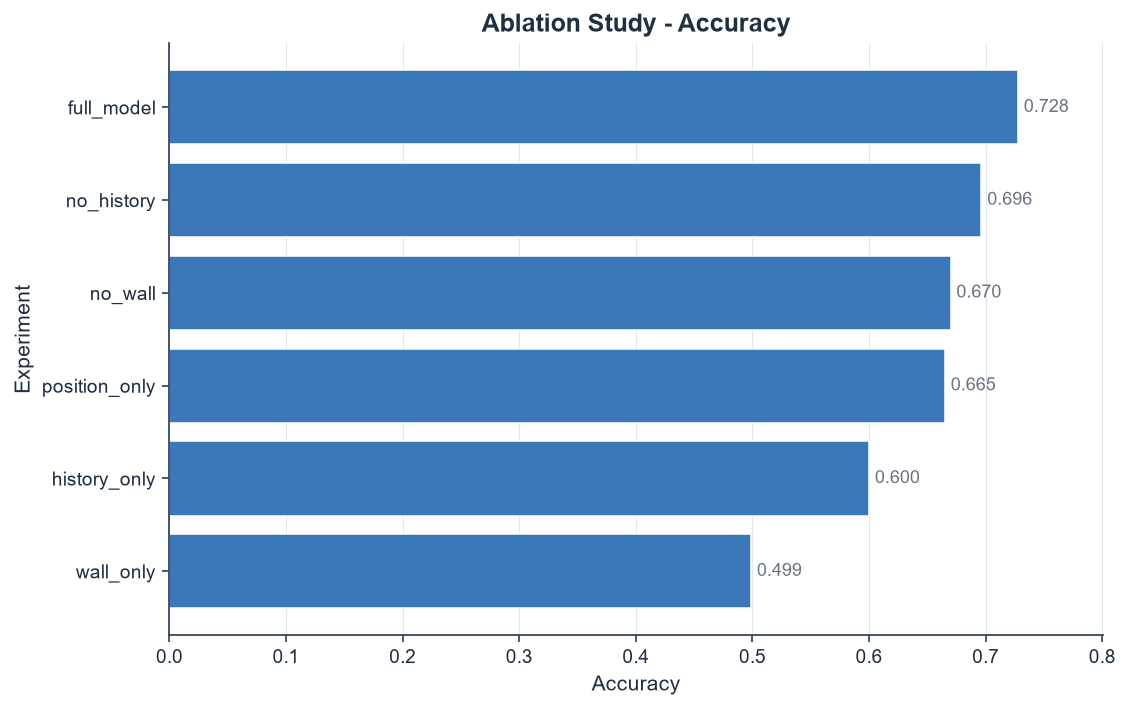

In [29]:
# Ablation study: accuracy
plot_df = ablation_df.sort_values("accuracy", ascending=True)
fig, ax = plt.subplots(figsize=(8.2, 5.2))

bars = ax.barh(
    plot_df["experiment"],
    plot_df["accuracy"],
    color=MCM_COLORS["blue"],
    edgecolor="white",
    linewidth=0.8,
)
ax.set_title("Ablation Study - Accuracy")
ax.set_xlabel("Accuracy")
ax.set_ylabel("Experiment")
ax.set_xlim(0, min(1.0, max(plot_df["accuracy"].max() * 1.10, 0.1)))
polish_axes(ax, grid_axis="x")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9,
        color=MCM_COLORS["gray"],
    )

save_figure(FIGURE_DIR / "ablation_accuracy.png")
plt.show()


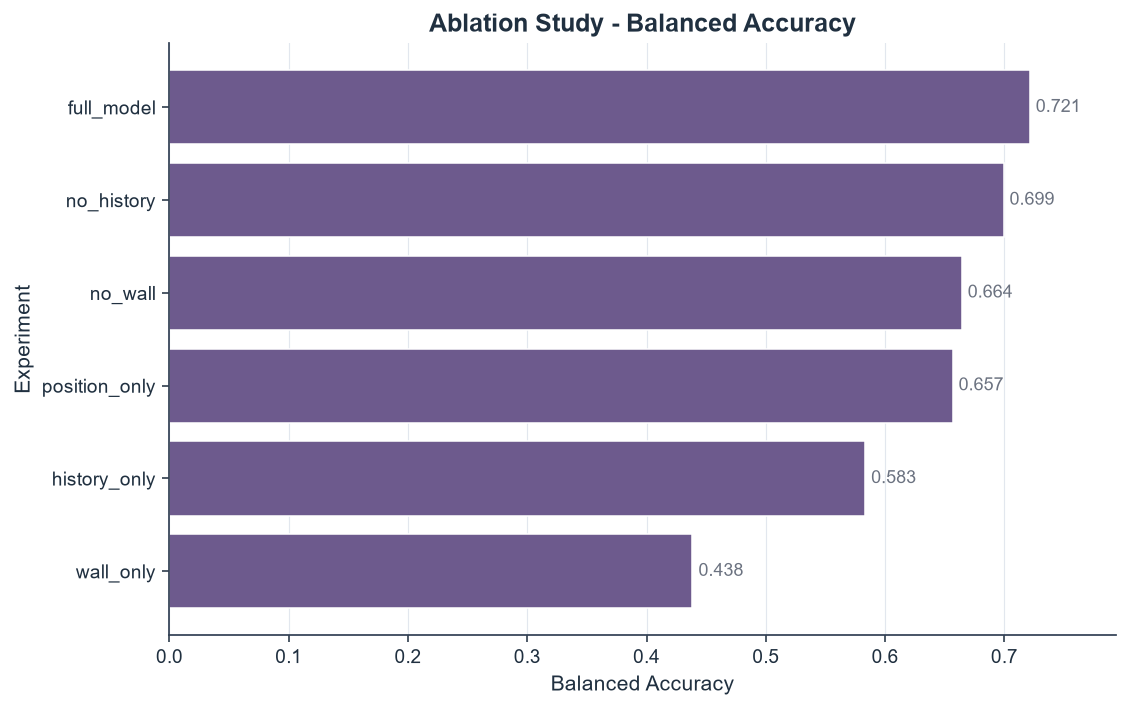

In [30]:
# Ablation study: balanced accuracy
plot_df = ablation_df.sort_values("balanced_accuracy", ascending=True)
fig, ax = plt.subplots(figsize=(8.2, 5.2))

bars = ax.barh(
    plot_df["experiment"],
    plot_df["balanced_accuracy"],
    color=MCM_COLORS["purple"],
    edgecolor="white",
    linewidth=0.8,
)
ax.set_title("Ablation Study - Balanced Accuracy")
ax.set_xlabel("Balanced Accuracy")
ax.set_ylabel("Experiment")
ax.set_xlim(0, min(1.0, max(plot_df["balanced_accuracy"].max() * 1.10, 0.1)))
polish_axes(ax, grid_axis="x")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left",
        fontsize=9,
        color=MCM_COLORS["gray"],
    )

save_figure(FIGURE_DIR / "ablation_balanced_accuracy.png")
plt.show()


## 5. Report-ready interpretation

The following cell generates a short paragraph that can be adapted into the final report.

In [31]:
best_ablation = ablation_df.iloc[0]
full_row = ablation_df[ablation_df["experiment"] == "full_model"].iloc[0]
no_history_row = ablation_df[ablation_df["experiment"] == "no_history"].iloc[0]
no_wall_row = ablation_df[ablation_df["experiment"] == "no_wall"].iloc[0]
top_features = importance_df.head(5)["feature"].tolist()

summary = f"""
The Random Forest model was evaluated on the collected replay log data for one-step human movement prediction.
The full model achieved an accuracy of {full_metrics['accuracy']:.4f} and a balanced accuracy of {full_metrics['balanced_accuracy']:.4f} on the test set.
The most influential features were {', '.join(top_features)}, indicating that player/monster positions, wall constraints, and movement history all contribute to the prediction.

In the ablation study, the full model obtained an accuracy of {full_row['accuracy']:.4f}.
Removing movement history reduced the accuracy to {no_history_row['accuracy']:.4f}, while removing wall information reduced it to {no_wall_row['accuracy']:.4f}.
This suggests that both historical movement information and surrounding wall information are useful for predicting the player's next direction.

Because the current replay log only stores feature-label pairs rather than complete trajectory information, this notebook evaluates one-step prediction accuracy.
A strict three-step rolling prediction error would require additional trajectory fields such as game_id, turn index, current human position, and the true future position after three steps.
"""

print(summary)


The Random Forest model was evaluated on the collected replay log data for one-step human movement prediction.
The full model achieved an accuracy of 0.7277 and a balanced accuracy of 0.7213 on the test set.
The most influential features were human_col, prev_down_1, human_row, monster_col, wall_up, indicating that player/monster positions, wall constraints, and movement history all contribute to the prediction.

In the ablation study, the full model obtained an accuracy of 0.7277.
Removing movement history reduced the accuracy to 0.6964, while removing wall information reduced it to 0.6699.
This suggests that both historical movement information and surrounding wall information are useful for predicting the player's next direction.

Because the current replay log only stores feature-label pairs rather than complete trajectory information, this notebook evaluates one-step prediction accuracy.
A strict three-step rolling prediction error would require additional trajectory fields such a

## 6. Outputs generated by this notebook

After running all cells, the following files will be created:

```text
models/direction_model_rf_16_features.pkl
results/feature_importance.csv
results/ablation_results.csv
results/shap_feature_importance.csv
results/figures/label_distribution.png
results/figures/confusion_matrix_full_model.png
results/figures/feature_importance_rf.png
results/figures/shap_beeswarm_main.png
results/figures/shap_beeswarm_down.png
results/figures/shap_beeswarm_left.png
results/figures/shap_beeswarm_right.png
results/figures/shap_beeswarm_up.png
results/figures/ablation_accuracy.png
results/figures/ablation_balanced_accuracy.png
```

Use these tables and figures in the report's **model evaluation** or **robustness analysis** section. The plots use a unified MCM-style academic color palette: clean white background, muted blue/teal/purple tones, and a blue-to-pink SHAP beeswarm color scale.
